In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# PREPROCESSING

In [2]:
hb = pd.read_csv("hotel_bookings.csv")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
hb.shape

(119390, 32)

In [5]:
hb.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,no,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,no,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,no,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,no,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,no,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [6]:
hb.shape

(119390, 32)

In [7]:
hb.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [8]:
hb.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [9]:
hb["hotel"].value_counts() # not a balanced data state

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [10]:
hb["is_canceled"].value_counts()

is_canceled
no     75166
yes    44224
Name: count, dtype: int64

In [11]:
hb["meal"].value_counts() # will merge SC and undefined - meaning no meal package 
# bb - bed and breakfast # hb-half board(2 meal) -dinner # fb-full board(3meal)

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

In [12]:
hb["market_segment"].value_counts() # TA -travel agents , TO - tour officer 

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [13]:
hb["distribution_channel"].value_counts() 

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [14]:
hb["deposit_type"].value_counts() 

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [15]:
hb["customer_type"].value_counts()  # Transient - booking is not a part of group or contract 
# Transient - booking means last minute booking

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [16]:
hb["total_of_special_requests"].value_counts() 

total_of_special_requests
0    70318
1    33226
2    12969
3     2497
4      340
5       40
Name: count, dtype: int64

<Axes: xlabel='hotel', ylabel='count'>

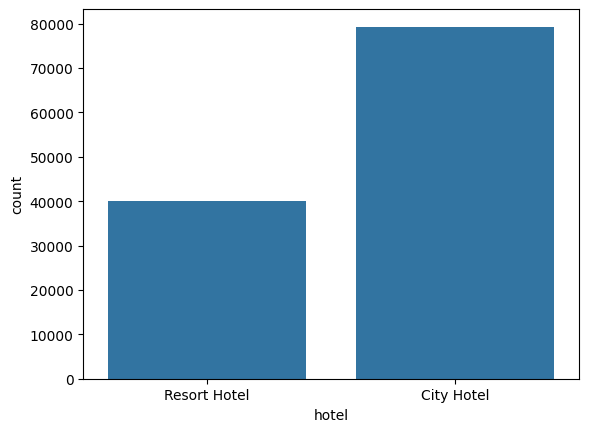

In [17]:
sns.countplot(data = hb , x = "hotel")

<Axes: xlabel='is_canceled', ylabel='count'>

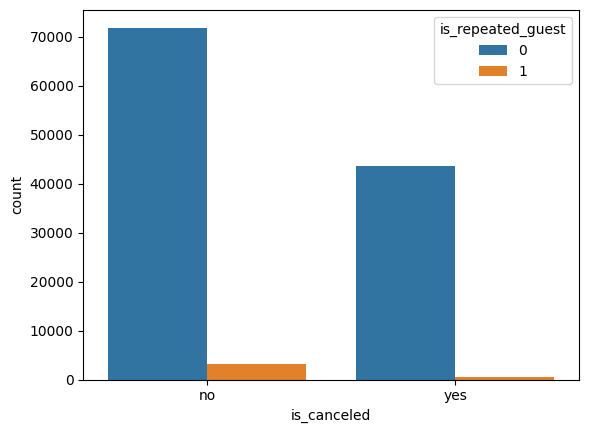

In [18]:
sns.countplot(data = hb , x = "is_canceled" , hue = "is_repeated_guest") # 0 - no 1 - yes

<Axes: xlabel='hotel', ylabel='count'>

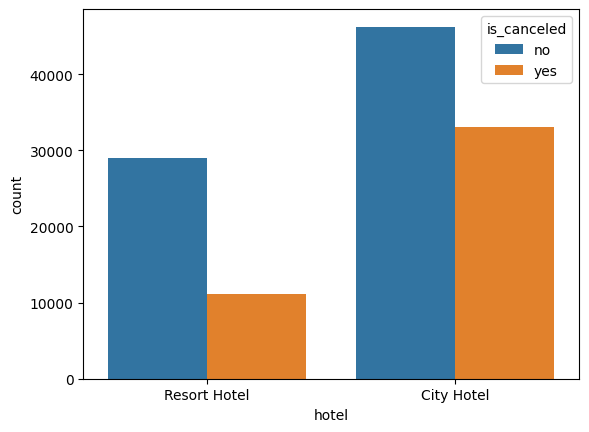

In [19]:
sns.countplot(data = hb ,  x = "hotel" , hue = "is_canceled")

---

**DATA PREPERATION**

In [20]:
hb.isnull().values.any()

np.True_

In [21]:
hb.isnull().sum()[hb.isnull().sum()>0]

children         4
country        488
agent        16340
company     112593
dtype: int64

In [22]:
# creating copy of dataframe

df_hb = hb.copy()

In [23]:
# Dataset Duplicate Value Count

df_hb[df_hb.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,no,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,7/3/2015
22,Resort Hotel,no,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,7/7/2015
43,Resort Hotel,no,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,7/7/2015
138,Resort Hotel,yes,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,7/1/2015
200,Resort Hotel,no,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,7/8/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,no,186,2017,August,35,31,0,3,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,9/3/2017
119352,City Hotel,no,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,9/3/2017
119353,City Hotel,no,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,9/3/2017
119354,City Hotel,no,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,9/3/2017


In [24]:
#  drop duplicate values

df_hb.drop_duplicates(inplace = True)

In [25]:
df_hb.shape

(87396, 32)

---

**Missing values / null values**

In [26]:
# replacing missing values with 0

df_hb.fillna(0 , inplace = True)

In [27]:
df_hb.isnull().sum()[hb.isnull().sum()>0]

children    0
country     0
agent       0
company     0
dtype: int64

In [28]:
# Meal contains values "Undefined" which is equal to SC
df_hb["meal"].replace("undefined" , "SC" , inplace = True)

In [29]:
df_hb["meal"].unique()

array(['BB', 'FB', 'HB', 'SC', 'Undefined'], dtype=object)

In [30]:
subset = df_hb[(df_hb["children"] ==  0) & (df_hb["adults"] == 0 ) & (df_hb["babies"] == 0 )]

In [31]:
subset[["adults" , 'babies' , "children"]] # 166 invalid entries

,adults,babies,children
2224,0,0,0.0
2409,0,0,0.0
3181,0,0,0.0
3684,0,0,0.0
3708,0,0,0.0
...,...,...,...
115029,0,0,0.0
115091,0,0,0.0
116251,0,0,0.0
116534,0,0,0.0


In [32]:
type(subset)

pandas.core.frame.DataFrame

In [33]:
delete = (df_hb["children"] == 0) & (df_hb["adults"] == 0 ) & (df_hb["babies"] == 0 )

In [34]:
type(delete)

pandas.core.series.Series

In [35]:
delete

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 87396, dtype: bool

In [36]:
data_hb = df_hb[~delete]  # where there is false it will become true known as negative delete

In [37]:
data_hb.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,no,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,no,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,no,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,no,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,no,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [38]:
subset = data_hb[(data_hb["children"] ==  0) & (data_hb["adults"] == 0 ) & (data_hb["babies"] == 0 )]
subset.head() # no invalid data is present 

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [39]:
data_hb.shape # we have deleted 166 records

(87230, 32)

In [40]:
87396 - 87230 # for checking purpose

166

In [41]:
data_hb.isnull().sum()[data_hb.isnull().sum()>0]

Series([], dtype: int64)

---

**Converting columns to appropriate datatypes.**

In [42]:
# Converting datatype of columns 'children', 'company' and 'agent' from float to int.
data_hb[['children', 'company', 'agent']] = data_hb[['children', 'company', 'agent']].astype('int64')

In [43]:
# changing datatype of column 'reservation_status_date' to data_type.

data_hb['reservation_status_date'] = pd.to_datetime(
    data_hb['reservation_status_date'],
    format='%m/%d/%Y'
)

---

**Adding important columns.**

In [44]:
# Adding total staying days in hotels
data_hb['total_stay'] = data_hb['stays_in_weekend_nights'] + data_hb['stays_in_week_nights']

# Adding total people num as column, i.e. total people num = num of adults + children + babies
data_hb['total_people'] = data_hb['adults'] + data_hb['children'] + data_hb['babies']

We are adding this column so that we can analyse the stay length at hotels.

---

# EDA

**Pie Chart for most preferred hotel (Univariate)**

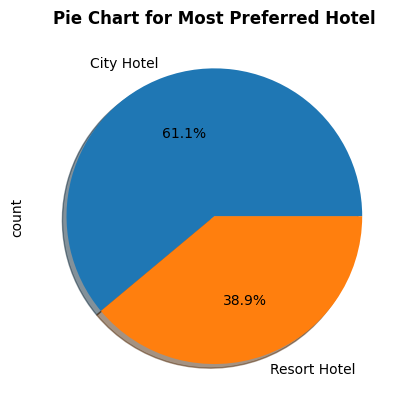

In [45]:
# Visualizing by pie chart
data_hb['hotel'].value_counts().plot.pie(shadow =  True ,  autopct ='%1.1f%%')

# Set labels
plt.title('Pie Chart for Most Preferred Hotel' , fontweight = "bold" )

# To show
plt.show()

**1. Why did you pick this chart?**

A pie chart clearly represents part-to-whole relationships and helps compare percentages easily. It is suitable for showing how total bookings are distributed between hotel types.

**2. Key insights from the chart**

City Hotels are more preferred, accounting for 61.1% of bookings, while 38.9% of guests choose Resort Hotels.

**3. Business impact of the insights**

City Hotels should continue leveraging their successful strategies, while Resort Hotels have clear growth potential by improving services and adopting effective practices from City Hotels.

---

**where do our guest come from which country ?**

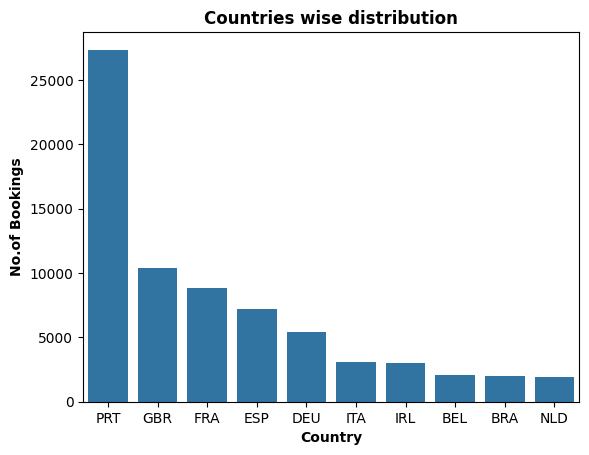

In [46]:
grp_by_country = data_hb.groupby('country')
d2 = pd.DataFrame(grp_by_country.size()).rename(columns = {0:'no. of bookings'}).sort_values('no. of bookings', ascending = False)
d2 = d2[:10]
sns.barplot(x = d2.index, y = d2['no. of bookings'])
plt.xlabel("Country" , fontweight = "bold")
plt.ylabel("No.of Bookings" , fontweight = "bold")
plt.title("Countries wise distribution" , fontweight = "bold")
plt.show()

people from all over the world are staying in these two hotels .
50 % of the guests are from Portugal , Great Britain and France.

**1. Why did you pick this chart?**

To identify the countries from which most hotel guests originate.

**2. Key insights from the chart**

Most customers come from Portugal, Great Britain, France, and Spain.

**3. Business impact of the insights**

These insights help target marketing and tailor services for key countries while also highlighting the need to diversify the customer base to reduce dependency risk.


---

**Correlation chart**

We first analyze correlations among numerical features. Columns such as is_canceled, date-related fields, is_repeated_guest, company, and agent are categorical in nature despite being numeric, so they are excluded from correlation analysis. Additionally, since total_stay and total_people are derived features, we remove their original component columns to avoid redundancy.

In [47]:
num_data_hb = data_hb[['lead_time','previous_cancellations','previous_bookings_not_canceled','booking_changes','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests','total_stay','total_people']]

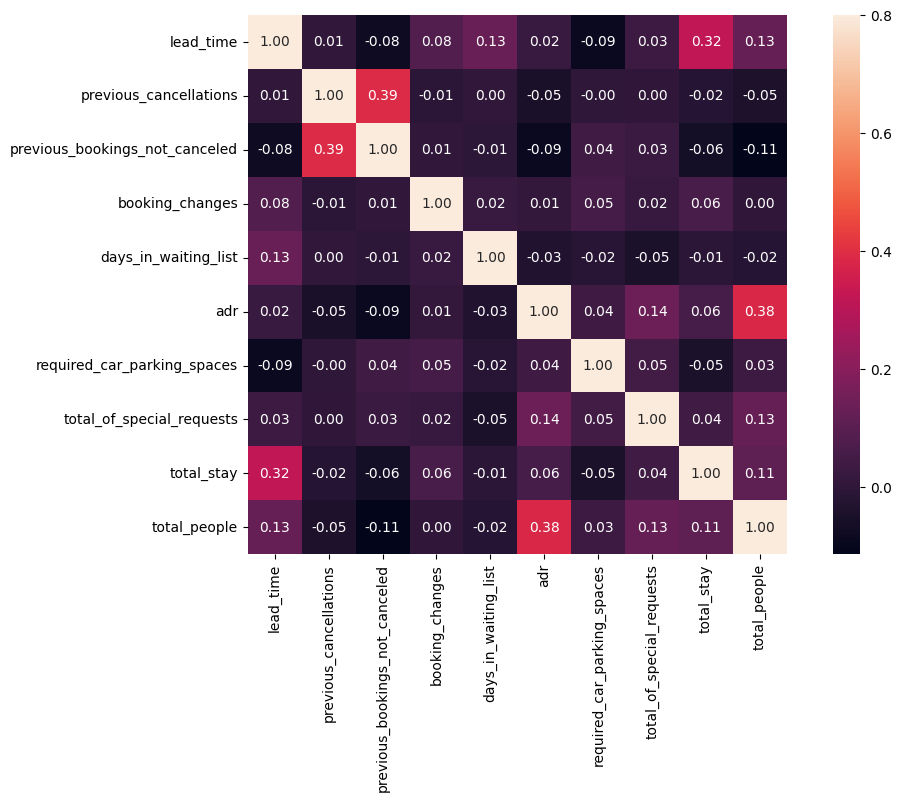

In [48]:
corrmat = num_data_hb.corr()
f, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(corrmat,annot = True,fmt='.2f', annot_kws={'size': 10},  vmax=.8, square=True);

**1. Why did you pick this chart?**

To analyze correlations among numerical variables and understand their relationships.

**2. Key insights from the chart**

Total stay length shows a slight correlation with lead time, indicating longer stays are often planned closer to arrival.

ADR is slightly correlated with total people, as larger groups tend to generate higher revenue.

**3. Business impact of the insights**

These insights support last-minute marketing for longer stays and group-based pricing strategies, while highlighting the need to balance short-term tactics with long-term planning.

---

**Relationship between ADR and Total Stay (Bivariate with Numerical-Numerical)**

In [50]:
# Chart - 3 visualization code
# Groupby adr, total_stay, hotel
adr_vs_total_stay = data_hb.groupby(['total_stay','adr','hotel']).agg('count').reset_index()
adr_vs_total_stay = adr_vs_total_stay.iloc[:, :3]
adr_vs_total_stay = adr_vs_total_stay.rename(columns = {'is_canceled':'number_of_stays'})
adr_vs_total_stay = adr_vs_total_stay[:18000]
adr_vs_total_stay

,total_stay,adr,hotel
0,0,0.00,City Hotel
1,0,0.00,Resort Hotel
2,1,0.00,City Hotel
3,1,0.00,Resort Hotel
4,1,1.00,City Hotel
...,...,...,...
17995,7,212.06,City Hotel
17996,7,212.10,Resort Hotel
17997,7,212.14,Resort Hotel
17998,7,212.29,City Hotel


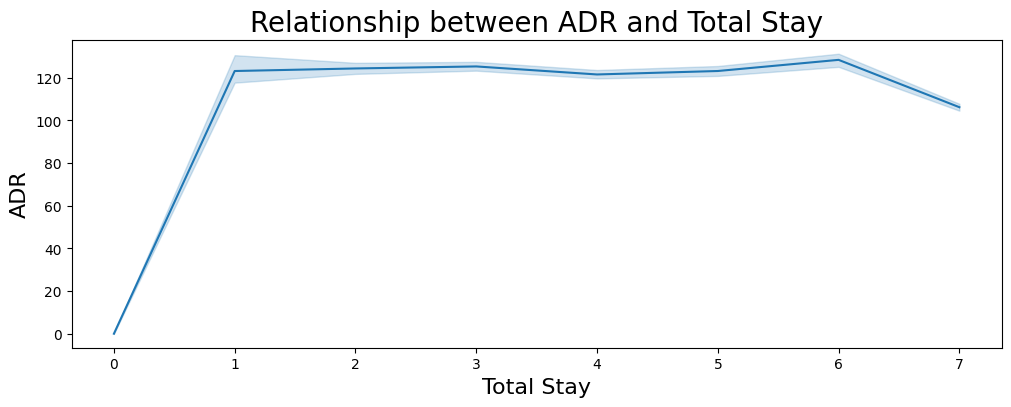

In [51]:
# Plotting the graph in line chart
# Set plot size
plt.figure(figsize=(12,4))

# Create the figure object
sns.lineplot(x= 'total_stay', y= 'adr', data= adr_vs_total_stay)

# Set labels
plt.xlabel('Total Stay', fontsize = 16)
plt.ylabel('ADR', fontsize = 16)
plt.title('Relationship between ADR and Total Stay', fontsize = 20)

# To show
plt.show()

**1. Why did you pick this chart?**

A line chart clearly shows trends and changes over time, making it easy to track increases and decreases.

**2. Key insights from the chart**

ADR increases as total stay increases, indicating a direct relationship between stay length and revenue.

**3. Business impact of the insights**

Hotels can boost revenue by encouraging longer stays through better offers, facilities, and targeted promotions.

---

**ADR across different months**

In [54]:
# Chart - 11 visualization code

# Using groupby funtion
bookings_by_months_df = data_hb.groupby(['arrival_date_month', 'hotel'])['adr'].mean().reset_index()

# Create month list
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# It will take the order of the month list in the dataframe along with values
bookings_by_months_df['arrival_date_month'] = pd.Categorical(bookings_by_months_df['arrival_date_month'], categories = months, ordered = True)

# Sorting values
bookings_by_months_df = bookings_by_months_df.sort_values('arrival_date_month')

bookings_by_months_df

,arrival_date_month,hotel,adr
8,January,City Hotel,85.269875
9,January,Resort Hotel,49.181693
6,February,City Hotel,89.266427
7,February,Resort Hotel,54.102809
15,March,Resort Hotel,57.590889
14,March,City Hotel,95.193911
0,April,City Hotel,117.314134
1,April,Resort Hotel,79.283805
17,May,Resort Hotel,80.551101
16,May,City Hotel,128.055724


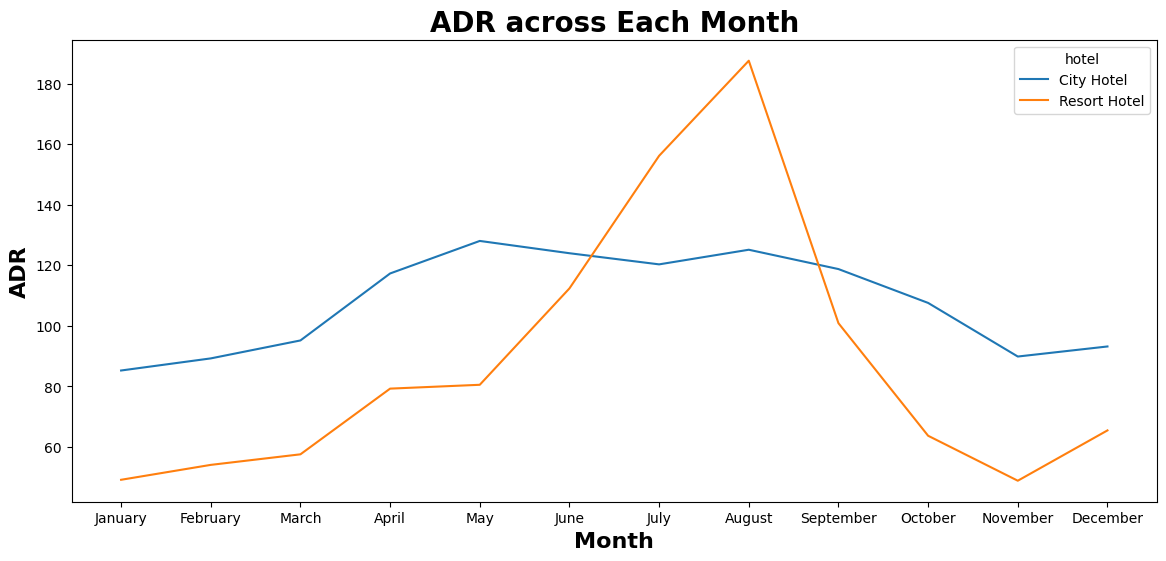

In [55]:
# Visualizing with the help of line plot

# Set plot size
plt.figure(figsize = (14,6))

# Create the figure object and plotting the line
sns.lineplot(x = bookings_by_months_df['arrival_date_month'], y = bookings_by_months_df['adr'], hue = bookings_by_months_df['hotel'])

# Set labels
plt.title('ADR across Each Month', fontsize = 20 , fontweight = "bold")
plt.xlabel('Month', fontsize = 16 , fontweight = "bold")
plt.ylabel('ADR', fontsize = 16 , fontweight = "bold")

# To show
plt.show()

**1. Why did you pick this chart?**

A line chart helps compare monthly ADR trends between City and Resort Hotels and clearly shows seasonal patterns.

**2. Key insights from the chart**

Resort Hotels have higher ADR during June–August, likely due to summer vacations.

ADR is lower in January–April and October–December, making these months more affordable for guests.

**3. Business impact of the insights**

Hotels can maximize revenue by capitalizing on peak-season demand and introducing attractive offers during low-ADR months to increase occupancy.


---

**Average ADR by hotel**

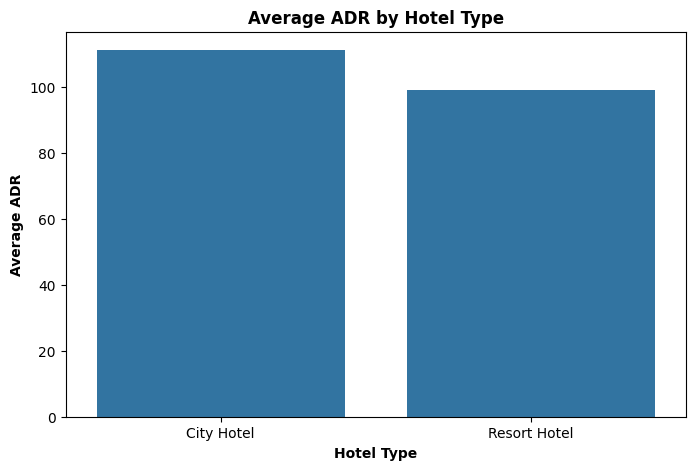

In [56]:
# Calculate average ADR by hotel type
avg_adr = (
    data_hb
    .groupby('hotel')['adr']
    .mean()
    .reset_index(name='Avg_ADR')
)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='hotel', y='Avg_ADR', data=avg_adr)
plt.xlabel("Hotel Type", fontweight="bold")
plt.ylabel("Average ADR", fontweight="bold")
plt.title("Average ADR by Hotel Type", fontweight="bold")
plt.show()

---

**Most preferred room types**

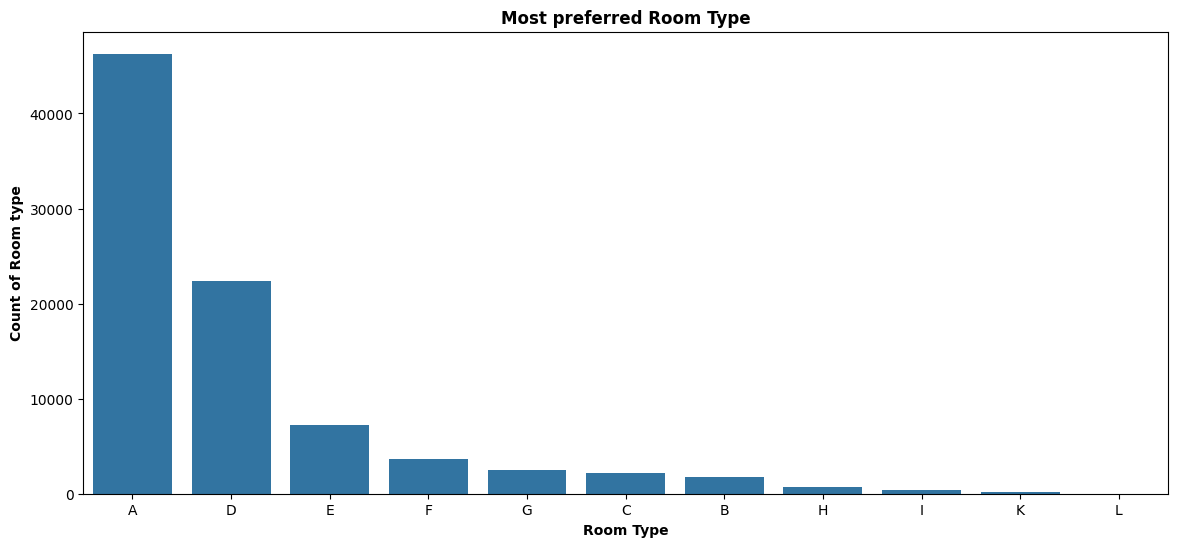

In [57]:
# visualization code

# Set the plot size
plt.figure(figsize = (14,6))

# Create the figure object
sns.countplot(x = data_hb['assigned_room_type'], order = data_hb['assigned_room_type'].value_counts().index)

# Set labels
plt.xlabel('Room Type' , fontweight = "bold")
plt.ylabel('Count of Room type' , fontweight = "bold" )
plt.title('Most preferred Room Type' , fontweight = "bold")

# To show
plt.show()

---

**Types of customers**

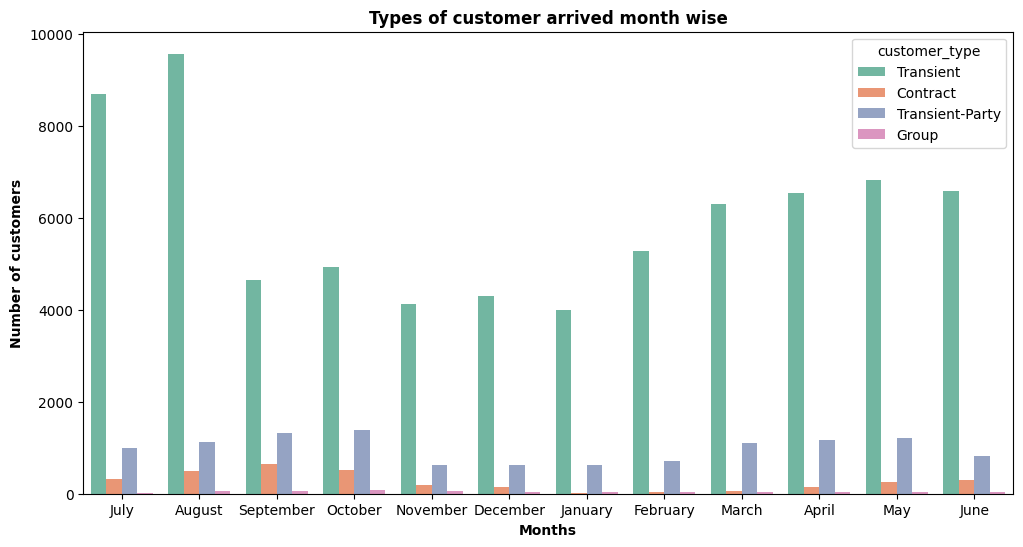

In [58]:
# Using seeborn to plot a count plot chart to demonstrate the types of customer visit the most
# Set the plot size
plt.figure(figsize = (12,6))

# Create the figure object
sns.countplot(x = 'arrival_date_month', hue = 'customer_type', palette = 'Set2', data = data_hb)

# Set labels
plt.xlabel('Months', fontweight = "bold")
plt.ylabel('Number of customers', fontweight = "bold")
plt.title('Types of customer arrived month wise', fontweight = "bold")

# To show
plt.show()

**1. Why did you pick this chart?**

A bar chart clearly shows the distribution of room types by booking count, while a count plot helps visualize the frequency of different guest types.

**2. Key insights from the chart**

Room type A is the most preferred by guests.

Transient customers form the largest guest segment, while group visitors are the least.

**3. Business impact of the insights**

Hotels can focus on maintaining and optimizing popular room types while improving less preferred ones. Understanding guest types also helps tailor services and offers, leading to higher bookings and increased revenue.

---

**cancelation and non cancelation**

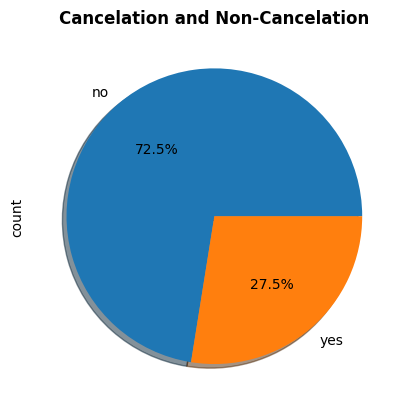

In [59]:
# Visualizing with the help of pie plot
data_hb['is_canceled'].value_counts().plot.pie( autopct = '%1.1f%%', shadow = True)

# Set title
plt.title('Cancelation and Non-Cancelation', fontweight = "bold")

# To show
plt.show()

**1. Why did you pick this chart?**

A pie chart clearly shows the proportion of canceled vs non-canceled bookings, making percentage comparison easy to understand at a glance.

**2. Key insights from the chart**

About 27.5% of total bookings are canceled, which is a significant share.

**3. Business impact of the insights**

This highlights a serious issue that requires analysis of cancellation reasons. Addressing these causes can help reduce cancellations and improve revenue stability.

---

**percentage of repeat guests**

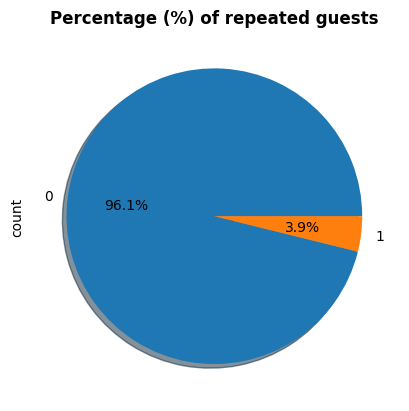

In [60]:
# visualization code

# Visualizing by pie chart
data_hb['is_repeated_guest'].value_counts().plot.pie(autopct ='%1.1f%%', shadow = True,  )

# Set labels
plt.title('Percentage (%) of repeated guests', fontweight = "bold")

# To show
plt.show()

**1. Why did you pick this chart?**

A pie chart clearly shows the proportion of repeated vs non-repeated guests, making percentage comparison easy to understand.

**2. Key insights from the chart**

Only 3.9% of guests are repeat customers, while 96.1% are first-time visitors, indicating low customer retention.

**3. Business impact of the insights**

Improving guest experience, collecting feedback, and offering loyalty benefits can increase repeat bookings and boost long-term revenue.

---

**Most booking chanel**

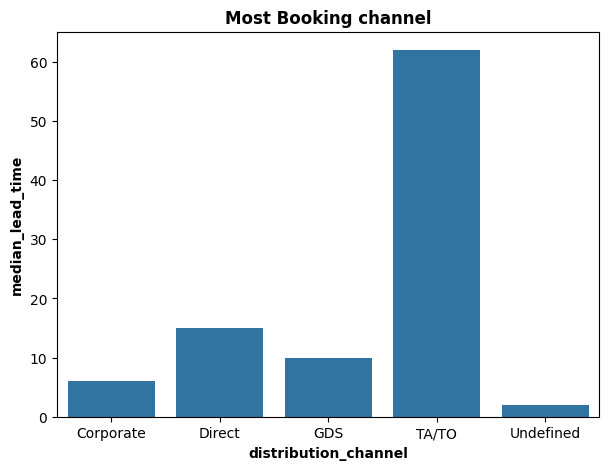

In [61]:
group_by_dc = data_hb.groupby('distribution_channel')
d2 = pd.DataFrame(round(group_by_dc['lead_time'].median(),2)).reset_index().rename(columns = {'lead_time': 'median_lead_time'})
plt.figure(figsize = (7,5))
sns.barplot(x = d2['distribution_channel'], y = d2['median_lead_time'])
plt.xlabel("distribution_channel" , fontweight = "bold")
plt.ylabel("median_lead_time" , fontweight = "bold")
plt.title("Most Booking channel" , fontweight = "bold")
plt.show()

**1. Why did you pick this chart?**

To identify which distribution channels are most commonly used for early hotel bookings.

**2. Key insights from the chart**

TA/TO is the most used channel for advance planning, while other channels are preferred for last-minute bookings.

**3. Business impact of the insights**

Hotels can strengthen partnerships with TA/TO for early bookings while also improving visibility on other channels to capture spontaneous travelers and maximize revenue.

---

**Average waiting Time through which booking channel**

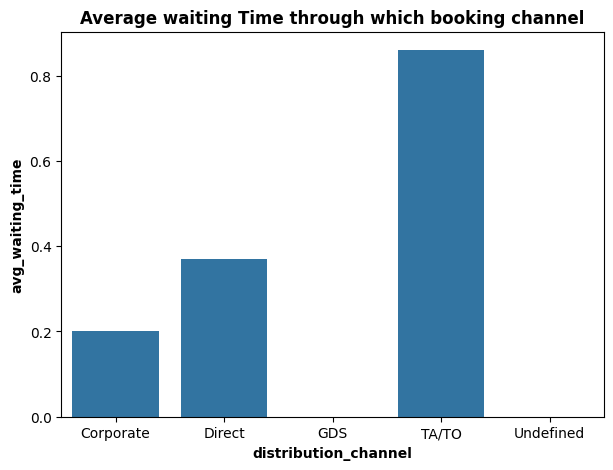

In [63]:
d4 = pd.DataFrame(round((group_by_dc['days_in_waiting_list']).mean(),2)).reset_index().rename(columns = {'days_in_waiting_list': 'avg_waiting_time'})
plt.figure(figsize = (7,5))
sns.barplot(x = d4['distribution_channel'], y = d4['avg_waiting_time'])
plt.xlabel("distribution_channel" , fontweight = "bold")
plt.ylabel("avg_waiting_time" , fontweight = "bold")
plt.title("Average waiting Time through which booking channel" , fontweight = "bold")
plt.show()

**1. Why did you pick this chart?**

To compare average waiting time across different booking channels.

**2. Key insights from the chart**

Bookings made through TA/TO tend to have longer confirmation waiting times.

**3. Business impact of the insights**

Reducing waiting times for TA/TO bookings can improve customer experience, prevent dissatisfaction, and help retain bookings and revenue.

---

**Total Stay in Each Hotel**

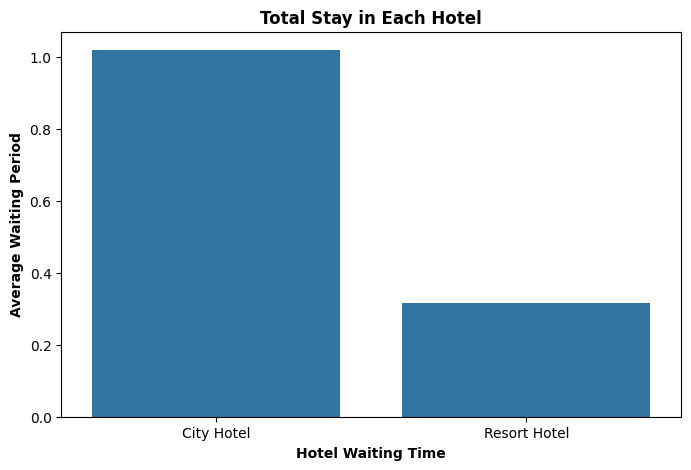

In [64]:
# Calculate average waiting time by hotel type
avg_waiting = (
    data_hb
    .groupby('hotel')['days_in_waiting_list']
    .mean()
    .reset_index(name='Avg_Waiting_Time')
)

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(
    x='hotel',
    y='Avg_Waiting_Time',
    data=avg_waiting
)

plt.xlabel("Hotel Waiting Time", fontweight="bold")
plt.ylabel("Average Waiting Period", fontweight="bold")
plt.title("Total Stay in Each Hotel", fontweight="bold")
plt.show()

---

**Total Stay in Each Hotel**

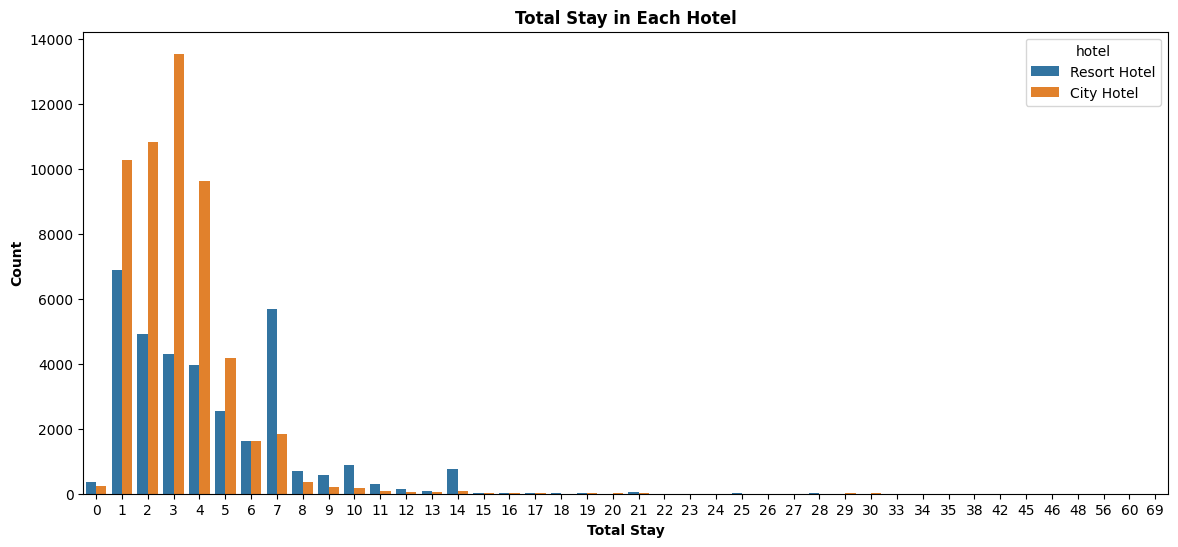

In [66]:
# Create total stay column
data_hb['total_stay'] = (
    data_hb['stays_in_weekend_nights'] +
    data_hb['stays_in_week_nights']
)

# Plot count of total stay for each hotel type
plt.figure(figsize=(14,6))
sns.countplot(
    x='total_stay',
    hue='hotel',
    data=data_hb
)

plt.xlabel("Total Stay", fontweight="bold")
plt.ylabel("Count", fontweight="bold")
plt.title("Total Stay in Each Hotel", fontweight="bold")
plt.legend(title='hotel')
plt.show()

---

**Cancellation Percentage via Distribution Channel**

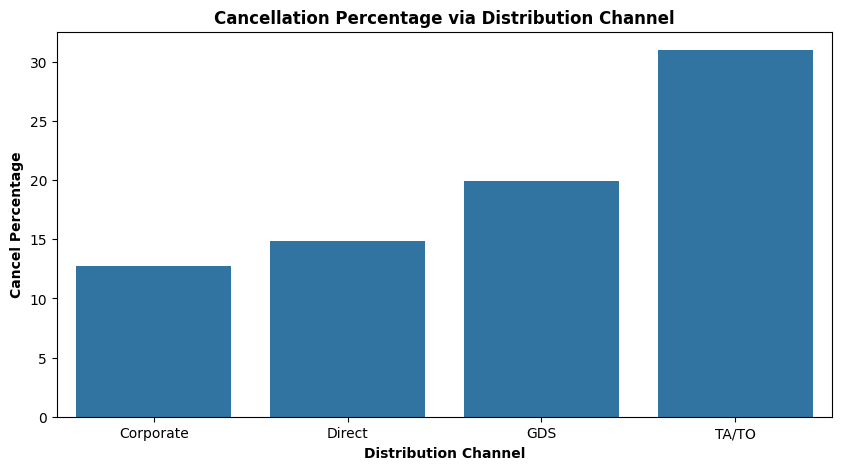

In [68]:
d1 = (
    data_hb.assign(
        is_canceled=data_hb['is_canceled'].map({'yes': 1, 'no': 0})
    )
    .groupby('distribution_channel')['is_canceled']
    .mean()
    .mul(100)
    .drop(index='Undefined')
    .to_frame(name='Cancel_%')
)

plt.figure(figsize=(10,5))
sns.barplot(x=d1.index, y=d1['Cancel_%'])
plt.xlabel("Distribution Channel", fontweight="bold")
plt.ylabel("Cancel Percentage", fontweight="bold")
plt.title("Cancellation Percentage via Distribution Channel", fontweight="bold")
plt.show()

---

**Revenue through distribution channel**

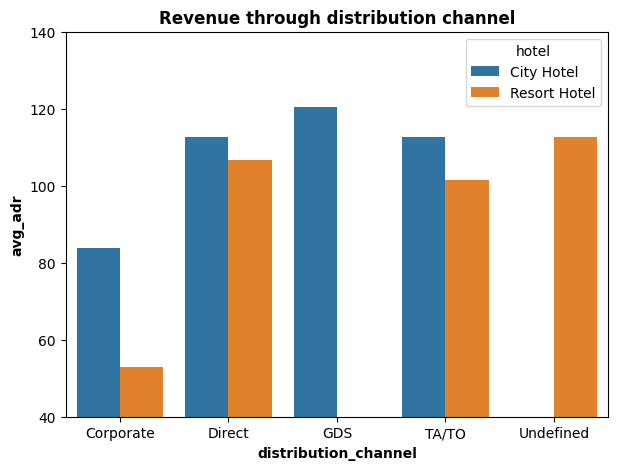

In [70]:
group_by_dc_hotel = data_hb.groupby(['distribution_channel', 'hotel'])
d5 = pd.DataFrame(round((group_by_dc_hotel['adr']).agg(np.mean),2)).reset_index().rename(columns = {'adr': 'avg_adr'})
plt.figure(figsize = (7,5))
sns.barplot(x = d5['distribution_channel'], y = d5['avg_adr'], hue = d5['hotel'])
plt.xlabel("distribution_channel" , fontweight = "bold")
plt.ylabel("avg_adr" , fontweight = "bold")
plt.title("Revenue through distribution channel" , fontweight = "bold")
plt.ylim(40,140)
plt.show()

---

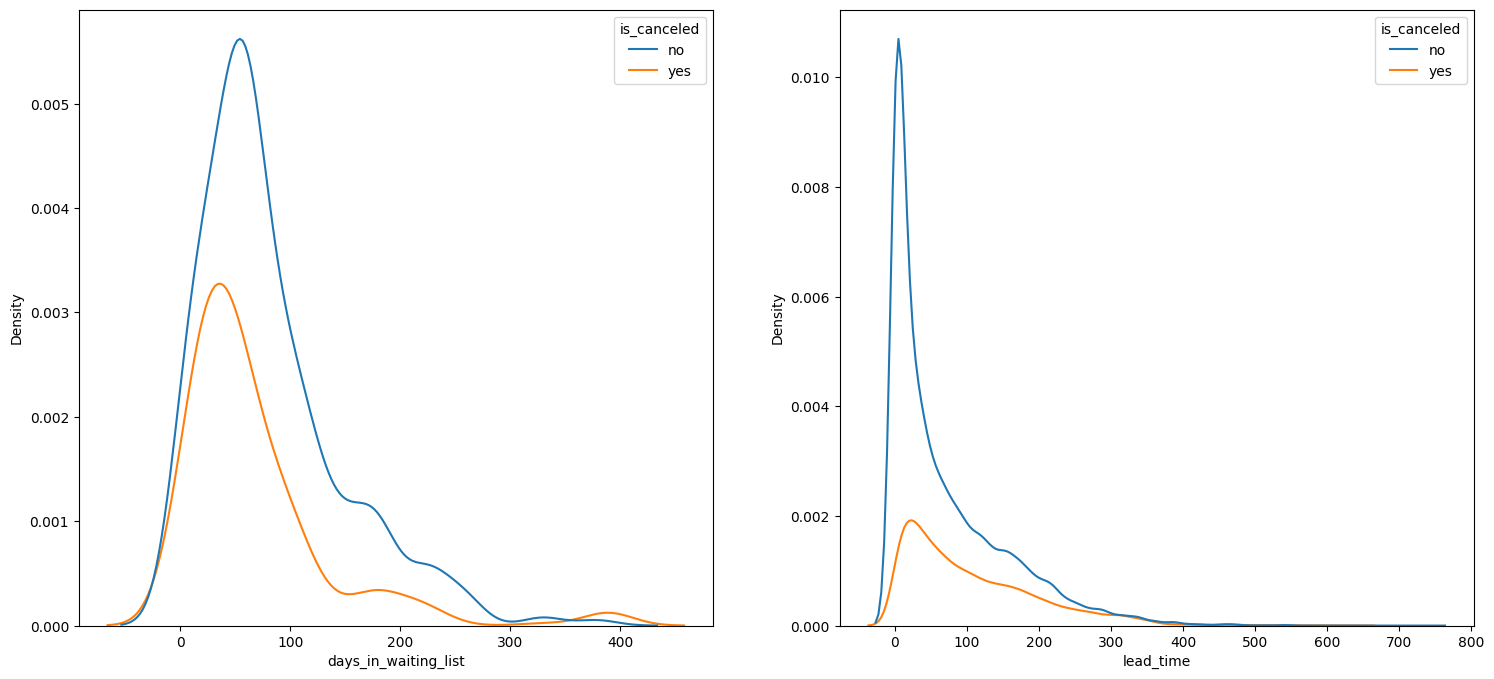

In [69]:
waiting_bookings = data_hb[data_hb['days_in_waiting_list'] !=0]  # Selecting bookings with non zero waiting time


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.kdeplot(ax=axes[0],x = 'days_in_waiting_list', hue = 'is_canceled' , data = waiting_bookings)
sns.kdeplot(ax = axes[1], x = data_hb['lead_time'], hue = data_hb['is_canceled'])
plt.show()

We see that most of the bookings that are cancelled have waiting period of less 150 days but also most of bookings that are not cancelled also have waiting period less than 150 days. Hence this shows that waiting period has no effect on cancellation of bookings.
Also, lead time has no affect on cancellation of bookings, as both curves of cancelation and not cncelation are similar for lead time too.

---

**Conclusion**

This project provides actionable insights for optimizing revenue and enhancing guest satisfaction in the City and Resort hotels. By diversifying the customer base, optimizing pricing, improving service efficiency, and enhancing marketing strategies, the client can achieve sustained growth. Addressing challenges such as high cancellation rates and over-reliance on specific booking channels is essential for long-term success. Overall, leveraging data-driven approaches and strategic planning will position the client for continued success in the competitive hotel industry.

---
***